In [1]:
import importlib, subprocess, sys
REQUIRED = {'facenet_pytorch': 'facenet-pytorch', 'scipy': 'scipy', 'kaggle': 'kaggle'}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [2]:
import os, json, glob, shutil, time, random, math, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch: 2.2.2+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-7':
    cand = LAB / 'lab-7'
    if cand.exists():
        LAB = cand.resolve()
DATA = LAB / 'data'
CELEBA_DIR = DATA / 'celeba'
FACES_DIR = DATA / 'faces_64'
RUNS_DIR = LAB / 'runs'
SAMPLES_DIR = LAB / 'samples'
RESULTS_PATH = LAB / 'results.json'

for p in [DATA, CELEBA_DIR, FACES_DIR, RUNS_DIR, SAMPLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 64
Z_DIM = 100
BATCH = 128
EPOCHS = 30
LR = 2e-4
BETA1 = 0.5
BETA2_DCGAN = 0.999
BETA2_WGAN = 0.9
WGAN_LR = 1e-4
N_CRITIC = 5
GP_LAMBDA = 10.0
SUBSET_SIZE = 30000
NUM_WORKERS = 4
SAMPLE_EVERY = 5
N_METRIC = 5000

print('LAB:', LAB)
print('device:', device)

LAB: /mnt/data/itmo-cv/lab-7
device: cuda


## 1. Загрузка CelebA

In [4]:
def find_celeba():
    imgs = next(iter(list(CELEBA_DIR.glob('**/img_align_celeba/img_align_celeba')) +
                     list(CELEBA_DIR.glob('**/img_align_celeba'))), None)
    attr = next(iter(CELEBA_DIR.glob('**/list_attr_celeba.csv')), None)
    return imgs, attr


celeba_imgs_root, celeba_attr = find_celeba()
if celeba_imgs_root is None or celeba_attr is None:
    print('downloading CelebA from Kaggle...')
    r = subprocess.run(['kaggle', 'datasets', 'download', '-d', 'jessicali9530/celeba-dataset',
                        '-p', str(CELEBA_DIR), '--unzip'], capture_output=False)
    if r.returncode != 0:
        raise SystemExit('kaggle download failed; check ~/.kaggle/kaggle.json')
    celeba_imgs_root, celeba_attr = find_celeba()

n_total = sum(1 for _ in celeba_imgs_root.glob('*.jpg'))
print(f'celeba images: {celeba_imgs_root} ({n_total} jpg)')
print(f'attributes:    {celeba_attr}')

attrs = pd.read_csv(celeba_attr).set_index('image_id')
print('attribute columns sample:', attrs.columns.tolist()[:6])
print('Male distribution:', dict(attrs['Male'].value_counts()))

celeba images: /mnt/data/itmo-cv/lab-7/data/celeba/img_align_celeba/img_align_celeba (202599 jpg)
attributes:    /mnt/data/itmo-cv/lab-7/data/celeba/list_attr_celeba.csv


attribute columns sample: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs']
Male distribution: {-1: 118165, 1: 84434}


## 2. Tight-crop через MTCNN

In [5]:
from facenet_pytorch import MTCNN

manifest_path = FACES_DIR / 'manifest.csv'
existing = sorted(FACES_DIR.glob('*.jpg'))

if len(existing) >= SUBSET_SIZE and manifest_path.exists():
    print(f'[skip] already cropped: {len(existing)} faces')
else:
    rng_pick = np.random.default_rng(0)
    all_ids = sorted(attrs.index.tolist())
    rng_pick.shuffle(all_ids)
    pick = all_ids[:int(SUBSET_SIZE * 1.2)]

    mtcnn = MTCNN(image_size=IMG_SIZE, margin=10, select_largest=True, post_process=False, device=device)
    saved = []
    for img_id in tqdm(pick, desc='cropping'):
        out = FACES_DIR / img_id
        if out.exists():
            saved.append((img_id, int(attrs.loc[img_id, 'Male'])))
            continue
        src = celeba_imgs_root / img_id
        if not src.exists():
            continue
        try:
            img = Image.open(src).convert('RGB')
            face = mtcnn(img)
        except Exception:
            continue
        if face is None:
            continue
        face_np = face.permute(1, 2, 0).byte().cpu().numpy()
        Image.fromarray(face_np).save(out, quality=95)
        saved.append((img_id, int(attrs.loc[img_id, 'Male'])))
        if len(saved) >= SUBSET_SIZE:
            break

    pd.DataFrame(saved, columns=['image_id', 'Male']).to_csv(manifest_path, index=False)
    print(f'saved {len(saved)} faces to {FACES_DIR}')

manifest = pd.read_csv(manifest_path)
manifest['label'] = (manifest['Male'] == 1).astype(int)
print(f'manifest: {len(manifest)} rows | male={manifest.label.sum()} female={(1-manifest.label).sum()}')

[skip] already cropped: 30000 faces
manifest: 30000 rows | male=12553 female=17447


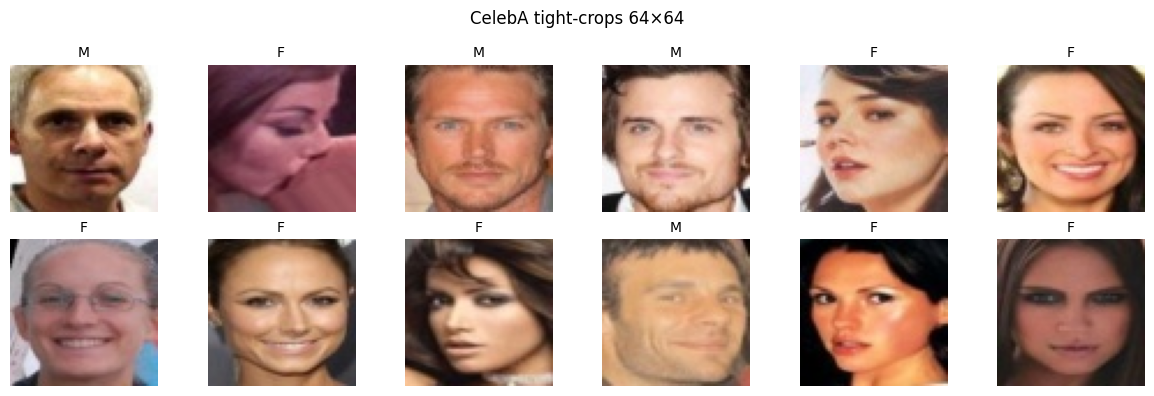

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, row in manifest.sample(12, random_state=0).reset_index(drop=True).iterrows():
    img = Image.open(FACES_DIR / row['image_id'])
    axes[i//6, i%6].imshow(img)
    axes[i//6, i%6].set_title('M' if row['label'] == 1 else 'F', fontsize=10)
    axes[i//6, i%6].axis('off')
plt.suptitle('CelebA tight-crops 64×64')
plt.tight_layout(); plt.show()

## 3. Dataset

In [7]:
class FacesDataset(Dataset):
    def __init__(self, manifest, root, with_label=False):
        self.items = manifest[['image_id', 'label']].values
        self.root = Path(root)
        self.with_label = with_label
        self.tf = transforms.Compose([
            transforms.Resize(IMG_SIZE),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        img_id, label = self.items[i]
        x = self.tf(Image.open(self.root / img_id).convert('RGB'))
        if self.with_label:
            return x, int(label)
        return x


ds_uncond = FacesDataset(manifest, FACES_DIR, with_label=False)
ds_cond = FacesDataset(manifest, FACES_DIR, with_label=True)
loader_uncond = DataLoader(ds_uncond, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
loader_cond = DataLoader(ds_cond, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
print('ds:', len(ds_uncond), 'batches/epoch:', len(loader_uncond))

ds: 30000 batches/epoch: 234


## 4. DCGAN — безусловная генерация

In [8]:
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64, use_sigmoid=True, norm='bn'):
        super().__init__()
        self.use_sigmoid = use_sigmoid
        N = nn.BatchNorm2d if norm == 'bn' else (lambda c: nn.InstanceNorm2d(c, affine=True))
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            N(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            N(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            N(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
        )
    def forward(self, x):
        out = self.net(x).view(-1)
        return torch.sigmoid(out) if self.use_sigmoid else out


G = Generator().to(device); G.apply(weights_init)
D = Discriminator(use_sigmoid=True, norm='bn').to(device); D.apply(weights_init)
print(f'G: {sum(p.numel() for p in G.parameters())/1e6:.2f}M | D: {sum(p.numel() for p in D.parameters())/1e6:.2f}M')
print('G output:', G(torch.randn(2, Z_DIM, 1, 1, device=device)).shape)

G: 3.58M | D: 2.77M
G output: torch.Size([2, 3, 64, 64])


In [9]:
def train_dcgan(G, D, loader, epochs, run_name, lr=LR, b1=BETA1, b2=BETA2_DCGAN):
    run_dir = RUNS_DIR / run_name; run_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = SAMPLES_DIR / run_name; samples_dir.mkdir(exist_ok=True)
    state_path = run_dir / 'state.pt'
    history_path = run_dir / 'history.csv'

    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(b1, b2))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(b1, b2))
    bce = nn.BCELoss()

    start_epoch = 0
    history = []
    if state_path.exists():
        sd = torch.load(state_path, map_location=device, weights_only=False)
        G.load_state_dict(sd['G']); D.load_state_dict(sd['D'])
        opt_g.load_state_dict(sd['opt_g']); opt_d.load_state_dict(sd['opt_d'])
        start_epoch = sd['epoch'] + 1
        if history_path.exists():
            history = pd.read_csv(history_path).values.tolist()
        print(f'[resume {run_name}] epoch={start_epoch}')
        if start_epoch >= epochs:
            print(f'[skip {run_name}] already trained {start_epoch} epochs')
            return history

    fixed_z = torch.randn(64, Z_DIM, 1, 1, device=device)
    t0 = time.time()
    for epoch in range(start_epoch, epochs):
        G.train(); D.train()
        d_losses, g_losses = [], []
        pbar = tqdm(loader, desc=f'{run_name} ep {epoch+1}/{epochs}')
        for real in pbar:
            real = real.to(device, non_blocking=True)
            bs = real.size(0)

            opt_d.zero_grad()
            d_real = D(real)
            loss_d_real = bce(d_real, torch.ones_like(d_real))
            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            fake = G(z).detach()
            d_fake = D(fake)
            loss_d_fake = bce(d_fake, torch.zeros_like(d_fake))
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward(); opt_d.step()

            opt_g.zero_grad()
            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            fake = G(z)
            d_fake = D(fake)
            loss_g = bce(d_fake, torch.ones_like(d_fake))
            loss_g.backward(); opt_g.step()

            d_losses.append(loss_d.item()); g_losses.append(loss_g.item())
            pbar.set_postfix(d=f'{loss_d.item():.3f}', g=f'{loss_g.item():.3f}')

        history.append([epoch, float(np.mean(d_losses)), float(np.mean(g_losses))])
        pd.DataFrame(history, columns=['epoch', 'd_loss', 'g_loss']).to_csv(history_path, index=False)
        torch.save({'G': G.state_dict(), 'D': D.state_dict(),
                    'opt_g': opt_g.state_dict(), 'opt_d': opt_d.state_dict(),
                    'epoch': epoch}, state_path)

        if (epoch + 1) % SAMPLE_EVERY == 0 or epoch == epochs - 1:
            G.eval()
            with torch.no_grad():
                fakes = G(fixed_z).detach().cpu()
            grid = make_grid(fakes, nrow=8, normalize=True, value_range=(-1, 1))
            save_image(grid, samples_dir / f'epoch_{epoch+1:03d}.png')

    print(f'{run_name} done: {(time.time()-t0)/60:.1f} min')
    return history


history_dcgan = train_dcgan(G, D, loader_uncond, EPOCHS, 'dcgan')

[resume dcgan] epoch=30
[skip dcgan] already trained 30 epochs


## 5. cGAN — условная генерация по полу

In [10]:
NUM_CLASSES = 2
EMB_DIM = 50


class CondGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM, n_classes=NUM_CLASSES, emb_dim=EMB_DIM, ngf=64):
        super().__init__()
        self.emb = nn.Embedding(n_classes, emb_dim)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim + emb_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z, y):
        e = self.emb(y).unsqueeze(-1).unsqueeze(-1)
        return self.net(torch.cat([z, e], dim=1))


class CondDiscriminator(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, ndf=64, use_sigmoid=True, norm='bn'):
        super().__init__()
        self.use_sigmoid = use_sigmoid
        self.label_map = nn.Embedding(n_classes, IMG_SIZE * IMG_SIZE)
        N = nn.BatchNorm2d if norm == 'bn' else (lambda c: nn.InstanceNorm2d(c, affine=True))
        self.net = nn.Sequential(
            nn.Conv2d(4, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            N(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            N(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            N(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
        )
    def forward(self, x, y):
        bs = x.size(0)
        lm = self.label_map(y).view(bs, 1, IMG_SIZE, IMG_SIZE)
        out = self.net(torch.cat([x, lm], dim=1)).view(-1)
        return torch.sigmoid(out) if self.use_sigmoid else out


Gc = CondGenerator().to(device); Gc.apply(weights_init)
Dc = CondDiscriminator(use_sigmoid=True, norm='bn').to(device); Dc.apply(weights_init)
print(f'Gc: {sum(p.numel() for p in Gc.parameters())/1e6:.2f}M | Dc: {sum(p.numel() for p in Dc.parameters())/1e6:.2f}M')
print('Gc output:', Gc(torch.randn(2, Z_DIM, 1, 1, device=device), torch.tensor([0, 1], device=device)).shape)

Gc: 3.99M | Dc: 2.77M


Gc output: torch.Size([2, 3, 64, 64])


In [11]:
def train_cgan(G, D, loader, epochs, run_name, lr=LR, b1=BETA1, b2=BETA2_DCGAN):
    run_dir = RUNS_DIR / run_name; run_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = SAMPLES_DIR / run_name; samples_dir.mkdir(exist_ok=True)
    state_path = run_dir / 'state.pt'
    history_path = run_dir / 'history.csv'

    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(b1, b2))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(b1, b2))
    bce = nn.BCELoss()

    start_epoch = 0
    history = []
    if state_path.exists():
        sd = torch.load(state_path, map_location=device, weights_only=False)
        G.load_state_dict(sd['G']); D.load_state_dict(sd['D'])
        opt_g.load_state_dict(sd['opt_g']); opt_d.load_state_dict(sd['opt_d'])
        start_epoch = sd['epoch'] + 1
        if history_path.exists():
            history = pd.read_csv(history_path).values.tolist()
        print(f'[resume {run_name}] epoch={start_epoch}')
        if start_epoch >= epochs:
            print(f'[skip {run_name}] already trained')
            return history

    fixed_z = torch.randn(64, Z_DIM, 1, 1, device=device)
    fixed_y = torch.tensor([i % NUM_CLASSES for i in range(64)], device=device)
    t0 = time.time()
    for epoch in range(start_epoch, epochs):
        G.train(); D.train()
        d_losses, g_losses = [], []
        pbar = tqdm(loader, desc=f'{run_name} ep {epoch+1}/{epochs}')
        for real, y in pbar:
            real = real.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            bs = real.size(0)

            opt_d.zero_grad()
            d_real = D(real, y)
            loss_d_real = bce(d_real, torch.ones_like(d_real))
            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            y_fake = torch.randint(0, NUM_CLASSES, (bs,), device=device)
            fake = G(z, y_fake).detach()
            d_fake = D(fake, y_fake)
            loss_d_fake = bce(d_fake, torch.zeros_like(d_fake))
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward(); opt_d.step()

            opt_g.zero_grad()
            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            y_g = torch.randint(0, NUM_CLASSES, (bs,), device=device)
            fake = G(z, y_g)
            d_fake = D(fake, y_g)
            loss_g = bce(d_fake, torch.ones_like(d_fake))
            loss_g.backward(); opt_g.step()

            d_losses.append(loss_d.item()); g_losses.append(loss_g.item())
            pbar.set_postfix(d=f'{loss_d.item():.3f}', g=f'{loss_g.item():.3f}')

        history.append([epoch, float(np.mean(d_losses)), float(np.mean(g_losses))])
        pd.DataFrame(history, columns=['epoch', 'd_loss', 'g_loss']).to_csv(history_path, index=False)
        torch.save({'G': G.state_dict(), 'D': D.state_dict(),
                    'opt_g': opt_g.state_dict(), 'opt_d': opt_d.state_dict(),
                    'epoch': epoch}, state_path)

        if (epoch + 1) % SAMPLE_EVERY == 0 or epoch == epochs - 1:
            G.eval()
            with torch.no_grad():
                fakes = G(fixed_z, fixed_y).detach().cpu()
            grid = make_grid(fakes, nrow=8, normalize=True, value_range=(-1, 1))
            save_image(grid, samples_dir / f'epoch_{epoch+1:03d}.png')

    print(f'{run_name} done: {(time.time()-t0)/60:.1f} min')
    return history


history_cgan = train_cgan(Gc, Dc, loader_cond, EPOCHS, 'cgan')

[resume cgan] epoch=30
[skip cgan] already trained


## 6. WGAN-GP (+5 баллов)

In [12]:
Gw = Generator().to(device); Gw.apply(weights_init)
Cw = Discriminator(use_sigmoid=False, norm='in').to(device); Cw.apply(weights_init)
print(f'Gw: {sum(p.numel() for p in Gw.parameters())/1e6:.2f}M | Cw: {sum(p.numel() for p in Cw.parameters())/1e6:.2f}M')


def gradient_penalty(critic, real, fake):
    bs = real.size(0)
    eps = torch.rand(bs, 1, 1, 1, device=real.device).expand_as(real)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    out = critic(interp)
    grads = torch.autograd.grad(
        outputs=out, inputs=interp,
        grad_outputs=torch.ones_like(out),
        create_graph=True, retain_graph=True,
    )[0]
    grads = grads.view(bs, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


def train_wgan_gp(G, C, loader, epochs, run_name, lr=WGAN_LR, b1=BETA1, b2=BETA2_WGAN,
                  n_critic=N_CRITIC, gp_lambda=GP_LAMBDA):
    run_dir = RUNS_DIR / run_name; run_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = SAMPLES_DIR / run_name; samples_dir.mkdir(exist_ok=True)
    state_path = run_dir / 'state.pt'
    history_path = run_dir / 'history.csv'

    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(b1, b2))
    opt_c = torch.optim.Adam(C.parameters(), lr=lr, betas=(b1, b2))

    start_epoch = 0
    history = []
    if state_path.exists():
        sd = torch.load(state_path, map_location=device, weights_only=False)
        G.load_state_dict(sd['G']); C.load_state_dict(sd['D'])
        opt_g.load_state_dict(sd['opt_g']); opt_c.load_state_dict(sd['opt_d'])
        start_epoch = sd['epoch'] + 1
        if history_path.exists():
            history = pd.read_csv(history_path).values.tolist()
        print(f'[resume {run_name}] epoch={start_epoch}')
        if start_epoch >= epochs:
            print(f'[skip {run_name}] already trained')
            return history

    fixed_z = torch.randn(64, Z_DIM, 1, 1, device=device)
    t0 = time.time()
    for epoch in range(start_epoch, epochs):
        G.train(); C.train()
        d_losses, g_losses = [], []
        pbar = tqdm(loader, desc=f'{run_name} ep {epoch+1}/{epochs}')
        critic_step = 0
        for real in pbar:
            real = real.to(device, non_blocking=True)
            bs = real.size(0)

            opt_c.zero_grad()
            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            fake = G(z).detach()
            c_real = C(real); c_fake = C(fake)
            gp = gradient_penalty(C, real, fake)
            loss_c = c_fake.mean() - c_real.mean() + gp_lambda * gp
            loss_c.backward(); opt_c.step()
            d_losses.append(loss_c.item())
            critic_step += 1

            if critic_step % n_critic == 0:
                opt_g.zero_grad()
                z = torch.randn(bs, Z_DIM, 1, 1, device=device)
                fake = G(z)
                loss_g = -C(fake).mean()
                loss_g.backward(); opt_g.step()
                g_losses.append(loss_g.item())
                pbar.set_postfix(c=f'{loss_c.item():.3f}', g=f'{loss_g.item():.3f}')

        history.append([epoch, float(np.mean(d_losses)), float(np.mean(g_losses)) if g_losses else 0.0])
        pd.DataFrame(history, columns=['epoch', 'd_loss', 'g_loss']).to_csv(history_path, index=False)
        torch.save({'G': G.state_dict(), 'D': C.state_dict(),
                    'opt_g': opt_g.state_dict(), 'opt_d': opt_c.state_dict(),
                    'epoch': epoch}, state_path)

        if (epoch + 1) % SAMPLE_EVERY == 0 or epoch == epochs - 1:
            G.eval()
            with torch.no_grad():
                fakes = G(fixed_z).detach().cpu()
            grid = make_grid(fakes, nrow=8, normalize=True, value_range=(-1, 1))
            save_image(grid, samples_dir / f'epoch_{epoch+1:03d}.png')

    print(f'{run_name} done: {(time.time()-t0)/60:.1f} min')
    return history


history_wgan = train_wgan_gp(Gw, Cw, loader_uncond, EPOCHS, 'wgan_gp')

Gw: 3.58M | Cw: 2.77M


[resume wgan_gp] epoch=30
[skip wgan_gp] already trained


## 7. FID и Inception Score

In [13]:
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights

_inception = None
def get_inception():
    global _inception
    if _inception is None:
        _inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                                   transform_input=False).to(device).eval()
    return _inception


def to_inception_input(imgs):
    x = (imgs + 1) / 2
    x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std


def inception_features(imgs, batch=64):
    m = get_inception()
    feats = []
    pool_hook = []
    def hook(mod, inp, out): pool_hook.append(out.detach())
    h = m.avgpool.register_forward_hook(hook)
    try:
        for i in range(0, len(imgs), batch):
            x = imgs[i:i+batch].to(device)
            pool_hook.clear()
            with torch.no_grad():
                m(to_inception_input(x))
            feats.append(pool_hook[0].squeeze(-1).squeeze(-1).cpu())
    finally:
        h.remove()
    return torch.cat(feats, dim=0).numpy()


def inception_logits(imgs, batch=64):
    m = get_inception()
    logits = []
    for i in range(0, len(imgs), batch):
        x = imgs[i:i+batch].to(device)
        with torch.no_grad():
            out = m(to_inception_input(x))
        logits.append(out.cpu())
    return torch.cat(logits, dim=0)


def fid_score(feats_real, feats_fake):
    mu_r, mu_f = feats_real.mean(0), feats_fake.mean(0)
    sig_r = np.cov(feats_real, rowvar=False)
    sig_f = np.cov(feats_fake, rowvar=False)
    diff = mu_r - mu_f
    covmean = sqrtm(sig_r @ sig_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


def inception_score(logits, splits=10):
    probs = F.softmax(logits, dim=1).numpy()
    n = probs.shape[0]
    scores = []
    for i in range(splits):
        part = probs[i*n//splits:(i+1)*n//splits]
        py = part.mean(0, keepdims=True)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        scores.append(np.exp(kl.sum(1).mean()))
    return float(np.mean(scores)), float(np.std(scores))

In [14]:
def collect_real(n):
    out = []
    for x in loader_uncond:
        out.append(x)
        if sum(t.size(0) for t in out) >= n:
            break
    return torch.cat(out, dim=0)[:n]


def generate_uncond(G_model, n, batch=128):
    G_model.eval()
    out = []
    with torch.no_grad():
        while sum(t.size(0) for t in out) < n:
            z = torch.randn(batch, Z_DIM, 1, 1, device=device)
            out.append(G_model(z).cpu())
    return torch.cat(out, dim=0)[:n]


def generate_cond(G_model, n, batch=128):
    G_model.eval()
    out = []
    with torch.no_grad():
        while sum(t.size(0) for t in out) < n:
            z = torch.randn(batch, Z_DIM, 1, 1, device=device)
            y = torch.randint(0, NUM_CLASSES, (batch,), device=device)
            out.append(G_model(z, y).cpu())
    return torch.cat(out, dim=0)[:n]


real_imgs = collect_real(N_METRIC)
feats_real = inception_features(real_imgs)
logits_real = inception_logits(real_imgs)
is_real_mean, is_real_std = inception_score(logits_real)
print(f'real IS: {is_real_mean:.3f} ± {is_real_std:.3f}')

metrics = {}
for name, gen_fn, model in [
    ('dcgan',  generate_uncond, G),
    ('cgan',   generate_cond,   Gc),
    ('wgan_gp', generate_uncond, Gw),
]:
    fakes = gen_fn(model, N_METRIC)
    f = inception_features(fakes)
    fid = fid_score(feats_real, f)
    lg = inception_logits(fakes)
    is_m, is_s = inception_score(lg)
    metrics[name] = {'FID': round(fid, 3), 'IS_mean': round(is_m, 3), 'IS_std': round(is_s, 3)}
    print(f'{name:8} FID={fid:.3f}  IS={is_m:.3f}±{is_s:.3f}')

metrics['real'] = {'IS_mean': round(is_real_mean, 3), 'IS_std': round(is_real_std, 3)}
metrics

real IS: 2.689 ± 0.123


dcgan    FID=40.584  IS=2.103±0.061


cgan     FID=159.141  IS=2.224±0.040


wgan_gp  FID=122.252  IS=2.437±0.037


{'dcgan': {'FID': 40.584, 'IS_mean': 2.103, 'IS_std': 0.061},
 'cgan': {'FID': 159.141, 'IS_mean': 2.224, 'IS_std': 0.04},
 'wgan_gp': {'FID': 122.252, 'IS_mean': 2.437, 'IS_std': 0.037},
 'real': {'IS_mean': 2.689, 'IS_std': 0.123}}

## 8. Кривые обучения

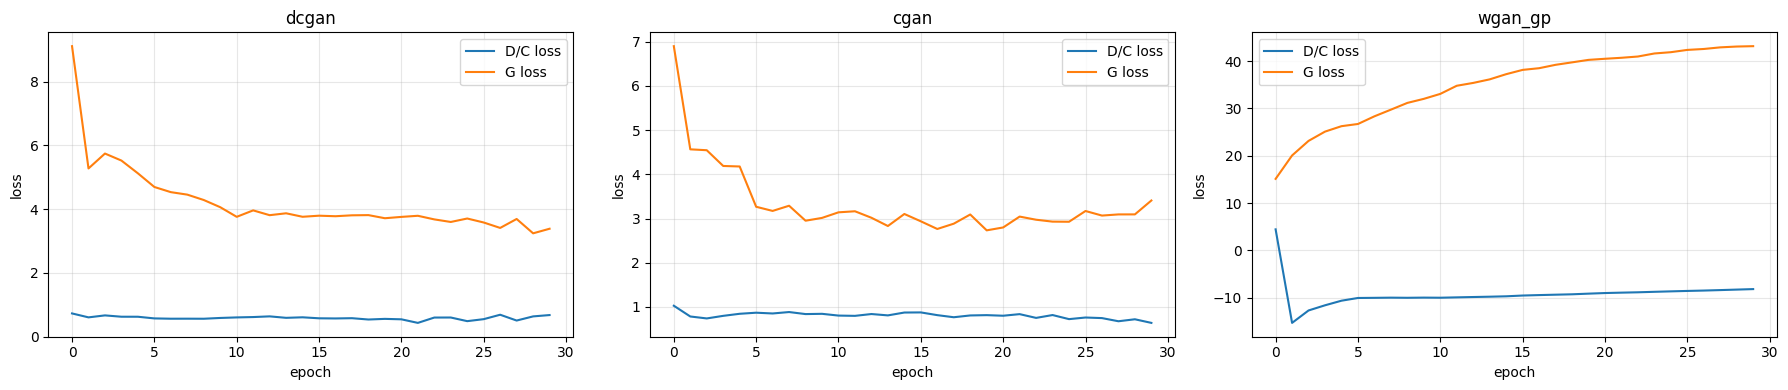

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, name in zip(axes, ['dcgan', 'cgan', 'wgan_gp']):
    df = pd.read_csv(RUNS_DIR / name / 'history.csv')
    ax.plot(df['epoch'], df['d_loss'], label='D/C loss')
    ax.plot(df['epoch'], df['g_loss'], label='G loss')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Финальные сэмплы 8×8 на каждую модель

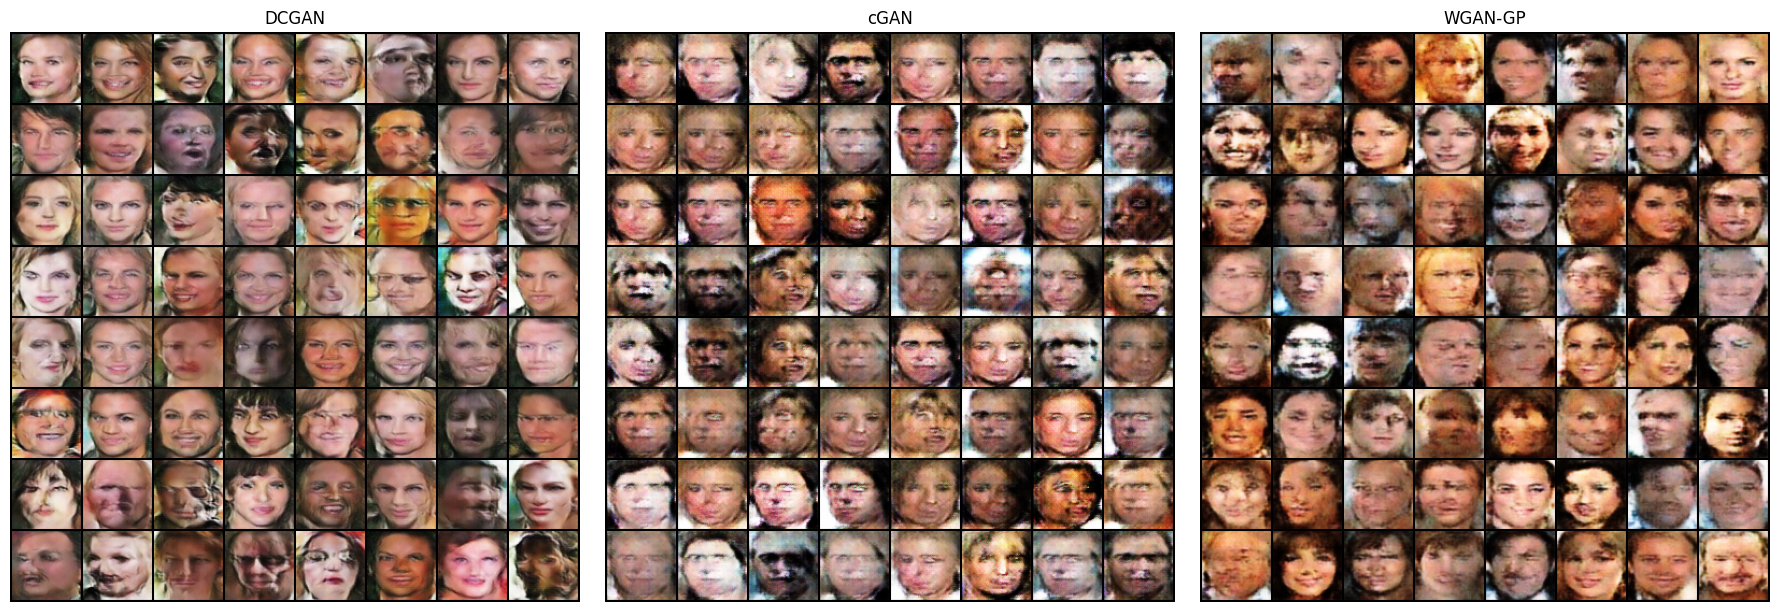

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name, gen_fn, model in [
    (axes[0], 'DCGAN',   generate_uncond, G),
    (axes[1], 'cGAN',    generate_cond,   Gc),
    (axes[2], 'WGAN-GP', generate_uncond, Gw),
]:
    fakes = gen_fn(model, 64)
    grid = make_grid(fakes, nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

## 10. cGAN — один и тот же z, разные метки

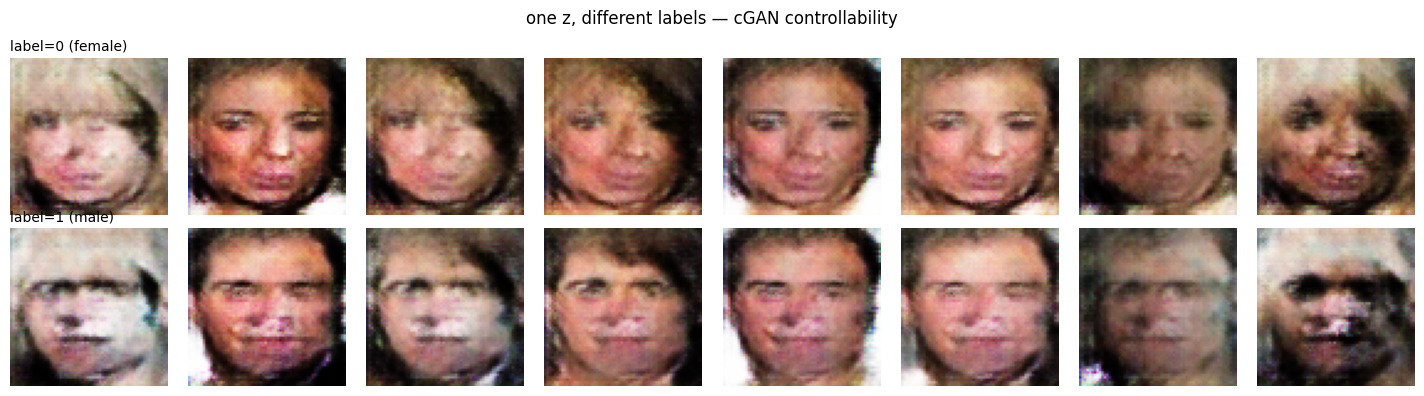

In [17]:
Gc.eval()
n_pairs = 8
z_shared = torch.randn(n_pairs, Z_DIM, 1, 1, device=device)
with torch.no_grad():
    fakes_f = Gc(z_shared, torch.zeros(n_pairs, dtype=torch.long, device=device)).cpu()
    fakes_m = Gc(z_shared, torch.ones(n_pairs, dtype=torch.long, device=device)).cpu()

fig, axes = plt.subplots(2, n_pairs, figsize=(n_pairs*1.8, 4))
for i in range(n_pairs):
    img_f = (fakes_f[i].permute(1, 2, 0).numpy() + 1) / 2
    img_m = (fakes_m[i].permute(1, 2, 0).numpy() + 1) / 2
    axes[0, i].imshow(np.clip(img_f, 0, 1)); axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(img_m, 0, 1)); axes[1, i].axis('off')
axes[0, 0].set_title('label=0 (female)', loc='left', fontsize=10)
axes[1, 0].set_title('label=1 (male)', loc='left', fontsize=10)
plt.suptitle('one z, different labels — cGAN controllability')
plt.tight_layout(); plt.show()

## 11. results.json

In [18]:
def csv_to_history(name):
    p = RUNS_DIR / name / 'history.csv'
    return pd.read_csv(p).to_dict(orient='list') if p.exists() else None


results = {
    'task': 'face_generation_GAN',
    'dataset': 'CelebA (kaggle jessicali9530/celeba-dataset)',
    'preprocessing': 'MTCNN tight-crop to 64x64',
    'subset_size': len(manifest),
    'img_size': IMG_SIZE,
    'conditional_attribute': 'Male (binary)',
    'models': {
        'dcgan':   'self-written DCGAN, unconditional',
        'cgan':    'same backbone, label embedding concatenated to z and as extra D channel',
        'wgan_gp': 'same backbone, sigmoid removed from D, InstanceNorm, gradient penalty, n_critic=5',
    },
    'hyperparameters': {
        'z_dim': Z_DIM, 'batch': BATCH, 'epochs': EPOCHS,
        'lr_dcgan': LR, 'lr_wgan': WGAN_LR,
        'beta1': BETA1, 'beta2_dcgan': BETA2_DCGAN, 'beta2_wgan': BETA2_WGAN,
        'n_critic': N_CRITIC, 'gp_lambda': GP_LAMBDA,
        'fid_is_samples': N_METRIC,
    },
    'metrics': metrics,
    'history': {k: csv_to_history(k) for k in ['dcgan', 'cgan', 'wgan_gp']},
}
RESULTS_PATH.write_text(json.dumps(results, indent=2, ensure_ascii=False))
print(json.dumps({'task': results['task'], 'subset_size': results['subset_size'],
                  'img_size': results['img_size'], 'metrics': results['metrics']},
                 indent=2, ensure_ascii=False))

{
  "task": "face_generation_GAN",
  "subset_size": 30000,
  "img_size": 64,
  "metrics": {
    "dcgan": {
      "FID": 40.584,
      "IS_mean": 2.103,
      "IS_std": 0.061
    },
    "cgan": {
      "FID": 159.141,
      "IS_mean": 2.224,
      "IS_std": 0.04
    },
    "wgan_gp": {
      "FID": 122.252,
      "IS_mean": 2.437,
      "IS_std": 0.037
    },
    "real": {
      "IS_mean": 2.689,
      "IS_std": 0.123
    }
  }
}
